# Open-Loop Optimal Control for a 3D Quadrotor Tracking an S-Shaped Trajectory

This notebook demonstrates how to formulate and solve an open-loop optimal control problem (OCP) for a full 3D quadrotor tracking a time-varying reference trajectory using the `OCP` class from the `model_predictive_control` package.

The quadrotor is modeled with 12 states (position, velocity, orientation, and angular rates) and 4 control inputs (individual motor thrusts).

In [1]:
import casadi as ca
import matplotlib.pyplot as plt
import numpy as np

from model_predictive_control.ocp import (
    OCP,
    control_bounds_constraints,
    state_bounds_constraints,
    terminal_tracking_objective,
    tracking_objective,
)
from model_predictive_control.plots import plot_controls, plot_states

## 1. System Dynamics

We define the physical parameters of the quadrotor and derive the non-linear 3D equations of motion.

States ($nx = 12$):
- $p$: Position in inertial frame $[x, y, z]$
- $v$: Velocity in inertial frame $[v_x, v_y, v_z]$
- $\eta$: Orientation (Euler angles Z-Y-X) $[\phi, \theta, \psi]$ (roll, pitch, yaw)
- $\omega$: Angular rates in body frame $[p, q, r]$

Controls ($nu = 4$):
- $T$: Individual motor thrusts $[T_1, T_2, T_3, T_4]$


In [2]:
# Physical parameters
m = 1.0       # Mass (kg)
g = 9.81      # Gravity (m/s^2)
l = 0.25      # Arm length (m)
c_tau = 0.01  # Thrust-to-torque coefficient

# Moments of inertia
J_x = 0.02
J_y = 0.02
J_z = 0.04
J = np.diag([J_x, J_y, J_z])
inv_J = np.linalg.inv(J)

# Dimensions
nx = 12
nu = 4

x = ca.MX.sym("x", nx)
u = ca.MX.sym("u", nu)

# Unpack states
p_pos = x[0:3]      # [x, y, z]
v_vel = x[3:6]      # [v_x, v_y, v_z]
eta = x[6:9]        # [phi, theta, psi]
omega = x[9:12]     # [p, q, r]

# Unpack controls
T1, T2, T3, T4 = u[0], u[1], u[2], u[3]
F_thrust = T1 + T2 + T3 + T4

# Torques
# Roll torque (tau_x): difference between left and right motors
tau_x = l * (T4 - T2)
# Pitch torque (tau_y): difference between front and back motors
tau_y = l * (T1 - T3)
# Yaw torque (tau_z): drag difference between CW and CCW motors
tau_z = c_tau * (T1 - T2 + T3 - T4)
tau = ca.vertcat(tau_x, tau_y, tau_z)

# Kinematics
phi, theta, psi = eta[0], eta[1], eta[2]

# Rotation matrix from Body to Inertial frame (Z-Y-X convention)
R_z = ca.vcat([
    ca.hcat([ca.cos(psi), -ca.sin(psi), 0]),
    ca.hcat([ca.sin(psi),  ca.cos(psi), 0]),
    ca.hcat([0,            0,           1])
])

R_y = ca.vcat([
    ca.hcat([ ca.cos(theta), 0, ca.sin(theta)]),
    ca.hcat([ 0,             1, 0           ]),
    ca.hcat([-ca.sin(theta), 0, ca.cos(theta)])
])

R_x = ca.vcat([
    ca.hcat([1, 0,           0          ]),
    ca.hcat([0, ca.cos(phi), -ca.sin(phi)]),
    ca.hcat([0, ca.sin(phi),  ca.cos(phi)])
])

R_IB = R_z @ R_y @ R_x

# Translational dynamics
g_vec = ca.vertcat(0, 0, -g)
# Thrust is in the body Z direction
T_B = ca.vertcat(0, 0, F_thrust)
v_dot = g_vec + (R_IB @ T_B) / m

# Rotational kinematics matrix (relating body rates to Euler rates)
W = ca.vcat([
    ca.hcat([1, ca.sin(phi)*ca.tan(theta), ca.cos(phi)*ca.tan(theta)]),
    ca.hcat([0, ca.cos(phi),              -ca.sin(phi)             ]),
    ca.hcat([0, ca.sin(phi)/ca.cos(theta), ca.cos(phi)/ca.cos(theta)])
])
eta_dot = W @ omega

# Rotational dynamics (Euler's equations)
omega_dot = inv_J @ (tau - ca.cross(omega, J @ omega))

# Full state derivative
x_dot = ca.vertcat(v_vel, v_dot, eta_dot, omega_dot)
dynamics = ca.Function("dynamics", [x, u], [x_dot])

## 2. Reference Trajectory (S-Shape)

We define an S-shaped trajectory for the quadrotor to track in the horizontal plane while maintaining a constant altitude. The quadrotor should maintain a zero yaw angle throughout the trajectory.

In [3]:
N = 50       # Horizon length
dt = 0.1     # Time step (s)
T_final = N * dt
time = np.arange(0, N + 1) * dt

# Pre-allocate reference arrays
X_ref = np.zeros((N + 1, nx))
U_ref = np.zeros((N, nu))

# Hover thrust for each motor
hover_thrust = m * g / 4.0

# Generate S-shape reference
# We use a combination of sine and linear functions
for k in range(N + 1):
    t = time[k]
    
    # X position progresses linearly
    X_ref[k, 0] = 1.0 * t  
    # Y position follows a sine wave to create the S-shape
    X_ref[k, 1] = 2.0 * np.sin(2 * np.pi * t / T_final) 
    # Z position stays constant at 1.0m altitude
    X_ref[k, 2] = 1.0  
    
    # Velocities (derivatives of positions)
    X_ref[k, 3] = 1.0  # v_x
    X_ref[k, 4] = 2.0 * (2 * np.pi / T_final) * np.cos(2 * np.pi * t / T_final) # v_y
    X_ref[k, 5] = 0.0  # v_z
    
    # All other states (angles and rates) are referenced to 0

for k in range(N):
    U_ref[k, :] = hover_thrust

## 3. Objective and Constraints

We use tracking objectives to penalize deviation from `X_ref` and `U_ref`. We also limit thrust and orientations.

In [4]:
# State weights
Q_diag = [
    100.0, 100.0, 200.0,  # Position: [x, y, z]
    10.0,  10.0,  10.0,   # Velocity: [v_x, v_y, v_z]
    10.0,  10.0,  50.0,   # Angles:   [phi, theta, psi]
    1.0,   1.0,   1.0     # Rates:    [p, q, r]
]
Q = np.diag(Q_diag)

# Control weights (penalize deviation from hover thrust)
R = np.diag([1.0, 1.0, 1.0, 1.0])

objective = tracking_objective(Q, R)

# Terminal state weights
Qf = Q * 5.0
terminal_objective = terminal_tracking_objective(Qf, np.zeros(nx))

# Constraints
# Control inputs limits
u_min_val = 0.0          # Minimum thrust (N)
u_max_val = 5.0          # Maximum thrust per motor (N)
u_min = np.array([u_min_val]*nu)
u_max = np.array([u_max_val]*nu)

# State limits
inf = 1e9
x_min = np.array([
    -inf, -inf, 0.0,            # Positions (z >= 0)
    -inf, -inf, -inf,           # Velocities
    -np.pi/3, -np.pi/3, -inf,   # Angles (limit roll and pitch to 60 deg)
    -inf, -inf, -inf            # Rates
])
x_max = np.array([
    inf, inf, inf,              # Positions
    inf, inf, inf,              # Velocities
    np.pi/3, np.pi/3, inf,      # Angles (limit roll and pitch to 60 deg)
    inf, inf, inf               # Rates
])

state_bounds = state_bounds_constraints(x_min, x_max, nu)
control_bounds = control_bounds_constraints(u_min, u_max, nx)

in_eq_constraints = ca.Function(
    "in_eq",
    [x, u],
    [ca.vertcat(state_bounds(x, u), control_bounds(x, u))]
)

## 4. Setup and Solve OCP

In [5]:
ocp = OCP(
    N=N,
    dt=dt,
    objective=objective,
    dynamics=dynamics,
    in_eq_constraints=in_eq_constraints,
    terminal_objective=terminal_objective
)

ocp.setup(
    method="collocation",
    dynamics_type="continuous",
    solver="ipopt",
    solver_opts={"print_level": 5, "max_iter": 2000}
)

# Initial state is the start of the reference trajectory
x0_val = X_ref[0, :].copy()

print("Solving quadrotor tracking OCP...")
X_opt, U_opt, status = ocp.solve(
    x0_val, 
    X_guess=X_ref, 
    U_guess=U_ref, 
    x_ref=X_ref, 
    u_ref=U_ref
)

print(f"\nSolver Status: {status}")

Solving quadrotor tracking OCP...



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     8312
Number of nonzeros in inequality constraint Jacobian.:     1600
Number of nonzeros in Lagrangian Hessian.............:     6077

Total number of variables............................:      812
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      612
Total number of inequality c

## 5. Visualize Results

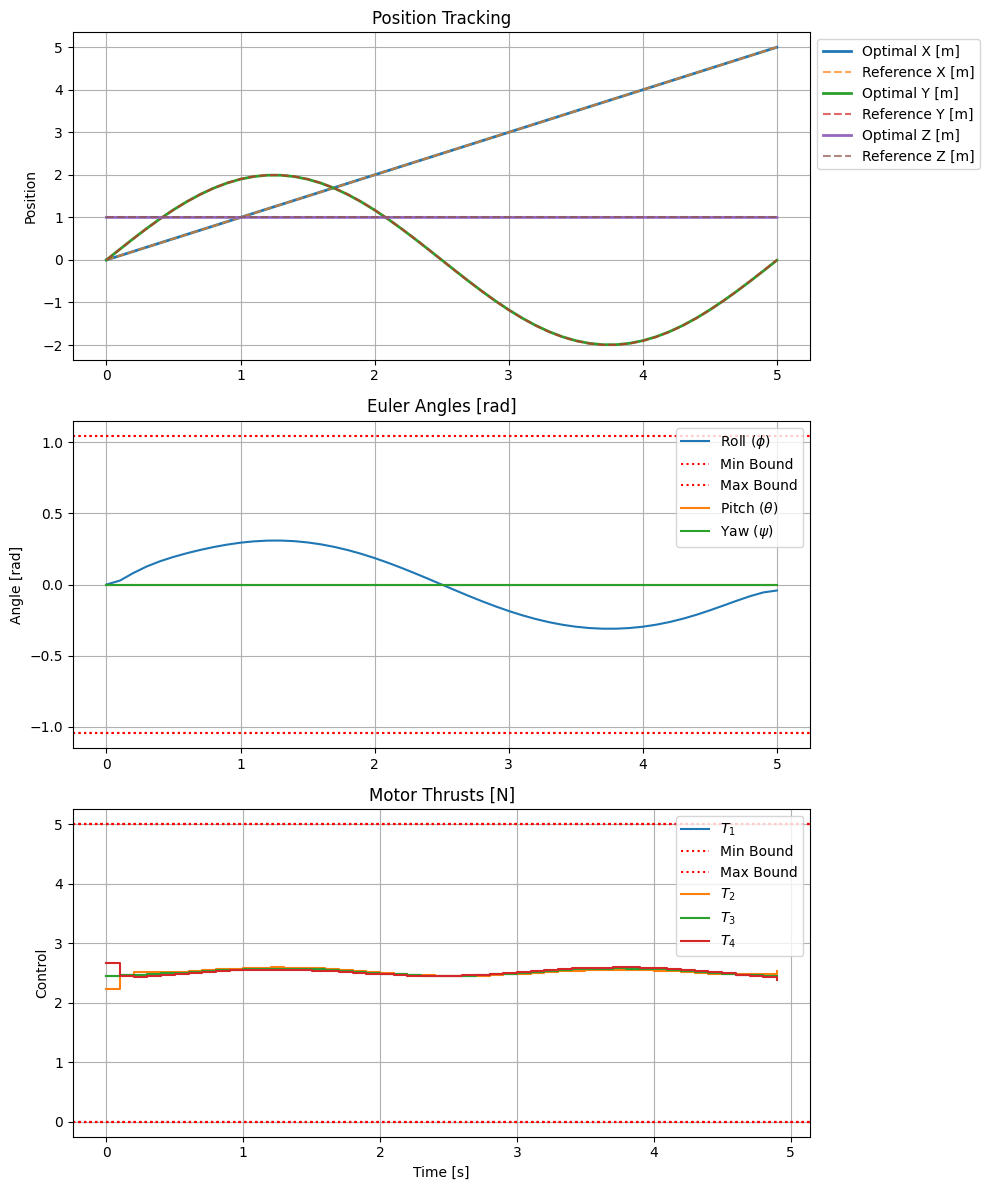

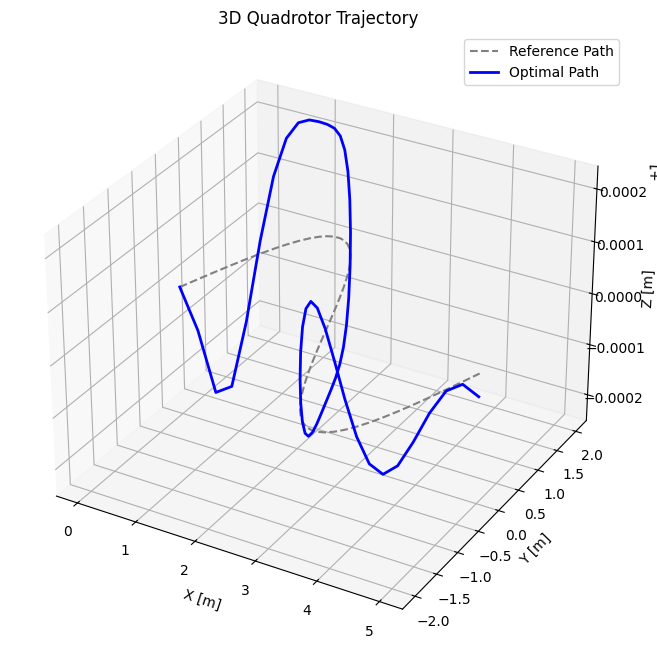

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Position X, Y, Z vs Reference
for i, (idx, label) in enumerate(zip([0, 1, 2], ['X [m]', 'Y [m]', 'Z [m]'])):
    axs[0].plot(time, X_opt[:, idx], label=f'Optimal {label}', linewidth=2)
    axs[0].plot(time, X_ref[:, idx], label=f'Reference {label}', linestyle='--', alpha=0.7)
axs[0].set_title("Position Tracking")
axs[0].set_ylabel("Position")
axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axs[0].grid(True)

# Euler Angles
plot_states(
    time,
    X_opt,
    indices=[6, 7, 8],
    labels=[r"Roll ($\phi$)", r"Pitch ($\theta$)", r"Yaw ($\psi$)"],
    fig=fig,
    ax=axs[1],
    title="Euler Angles [rad]",
    ylabel="Angle [rad]",
    bounds=[(-np.pi/3, np.pi/3), (-np.pi/3, np.pi/3), None]
)

# Controls
plot_controls(
    time,
    U_opt,
    labels=["$T_1$", "$T_2$", "$T_3$", "$T_4$"],
    fig=fig,
    ax=axs[2],
    title="Motor Thrusts [N]",
    bounds=[(u_min_val, u_max_val)] * 4,
    step=True
)

plt.tight_layout()
plt.show()

# 3D Path Plot
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')
ax_3d.plot(X_ref[:, 0], X_ref[:, 1], X_ref[:, 2], '--', color='gray', label='Reference Path')
ax_3d.plot(X_opt[:, 0], X_opt[:, 1], X_opt[:, 2], '-b', linewidth=2, label='Optimal Path')
ax_3d.set_xlabel('X [m]')
ax_3d.set_ylabel('Y [m]')
ax_3d.set_zlabel('Z [m]')
ax_3d.set_title('3D Quadrotor Trajectory')
ax_3d.legend()
plt.show()